# Desarollo de ejemeplos del elementos finito tipo Truss 2D con 2 grados de libertad
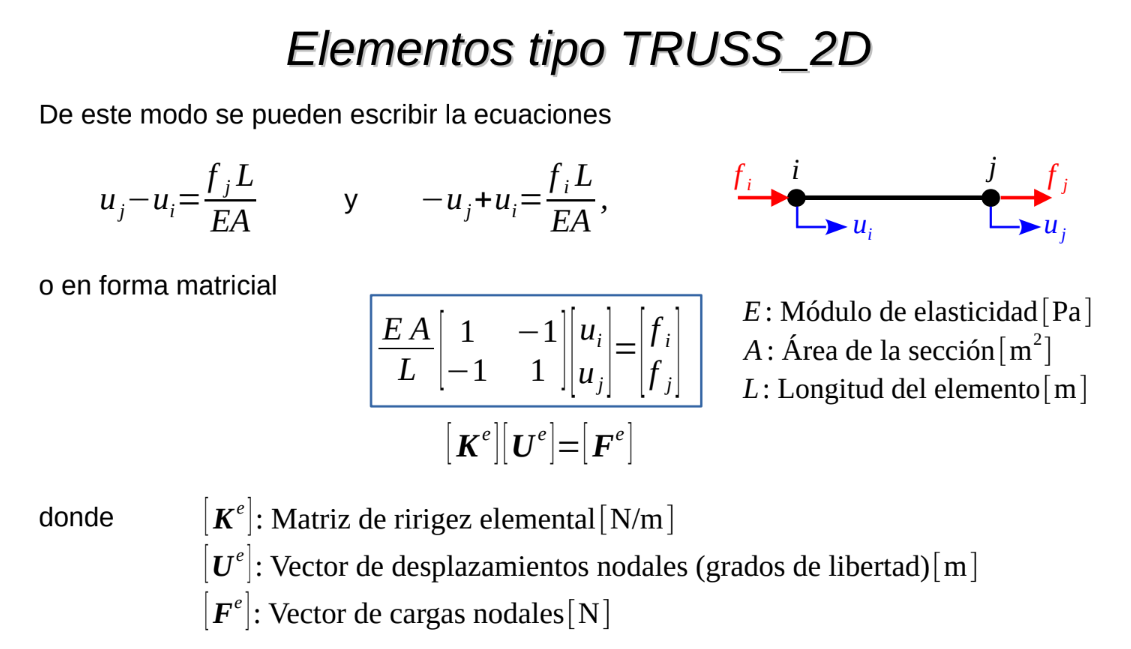
Para el desarrollo de cualquiera de los codigos que emplearemos en elementos finitos podemos definir 3 funciones, seguimos la lógica de trabajo


La matriz mostrada en la dispositiva es la matriz elemental de un elementos finito tipo truss. Definiremos una función llamada matriz elemental en donde siempre vamos a programar la forma de la matriz elemental dependiendo del elementos finito que vayamos a trabajar 
# Para trabajar matrices (arreglos) lo mas comodo es numpy si conoce otro uselo :)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
def K_e(Mnod, Melem, e):
    """
    Calcula la matriz de rigidez elemental (Ke) para un elemento de barra 1D (TRUSS).

    Parámetros:
    ------------
    Mnod : ndarray
        Matriz de nodos con coordenadas nodales (x).
    Melem : ndarray
        Matriz de conectividades y propiedades de cada elemento (nodo1, nodo2, E, A).
    e : int
        Índice del elemento a procesar.

    Retorna:
    ---------
    Ke : ndarray
        Matriz de rigidez del elemento e (2x2).
    """
    nod1 = int(Melem[e, 0]) - 1
    nod2 = int(Melem[e, 1]) - 1
    x1 = Mnod[nod1, 0]
    x2 = Mnod[nod2, 0]
    L = x2 - x1
    E = Melem[e, 2]
    A = Melem[e, 3]
    Ke = (E * A / L) * np.array([[1, -1], [-1, 1]], dtype=np.float64)
    return Ke



* El paso a seguir se describe en la diapositiva y en nomenclatura de elementos finitos como ensamble consiste en juntar los elementos finitos y crear un arreglo de elementos finitos que representen la geometría de nuestro problema
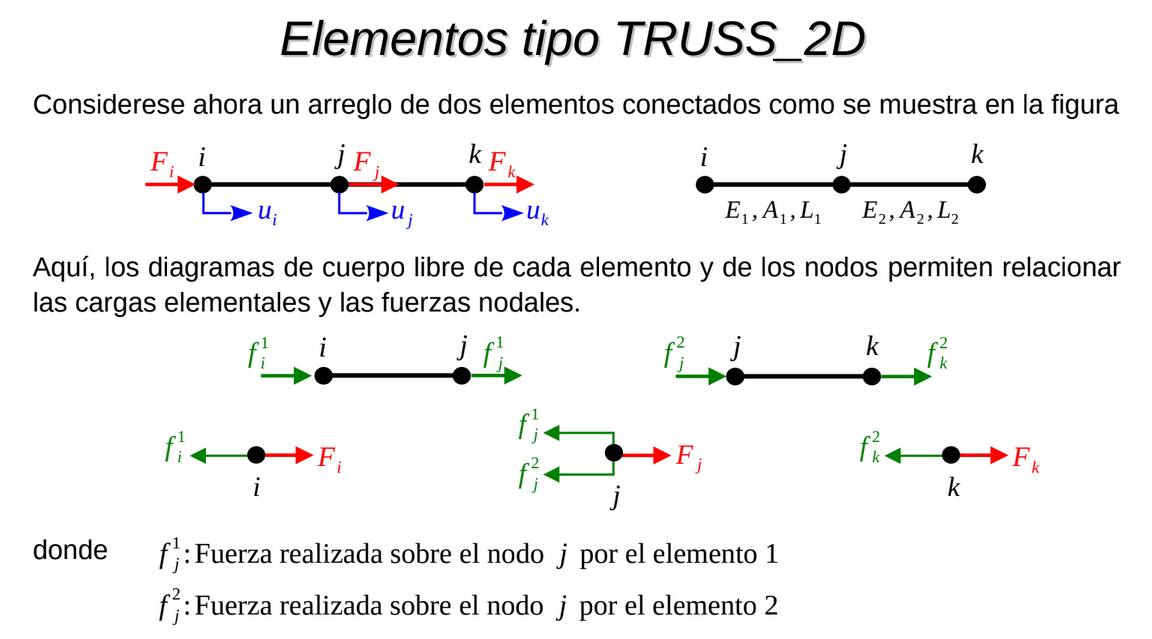
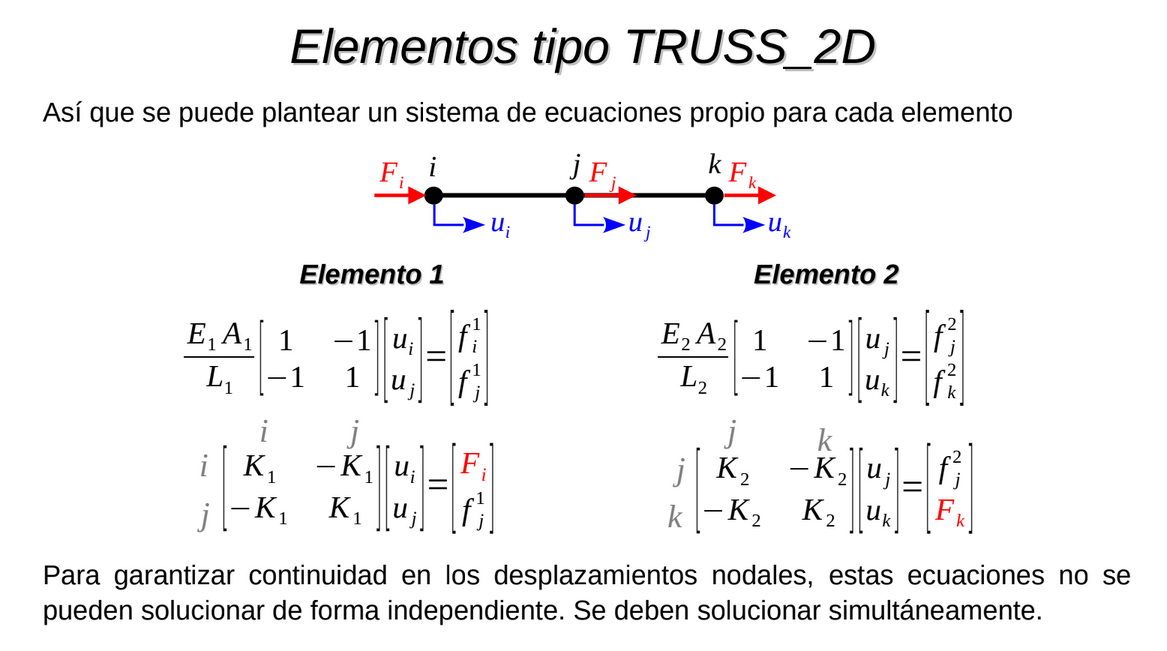
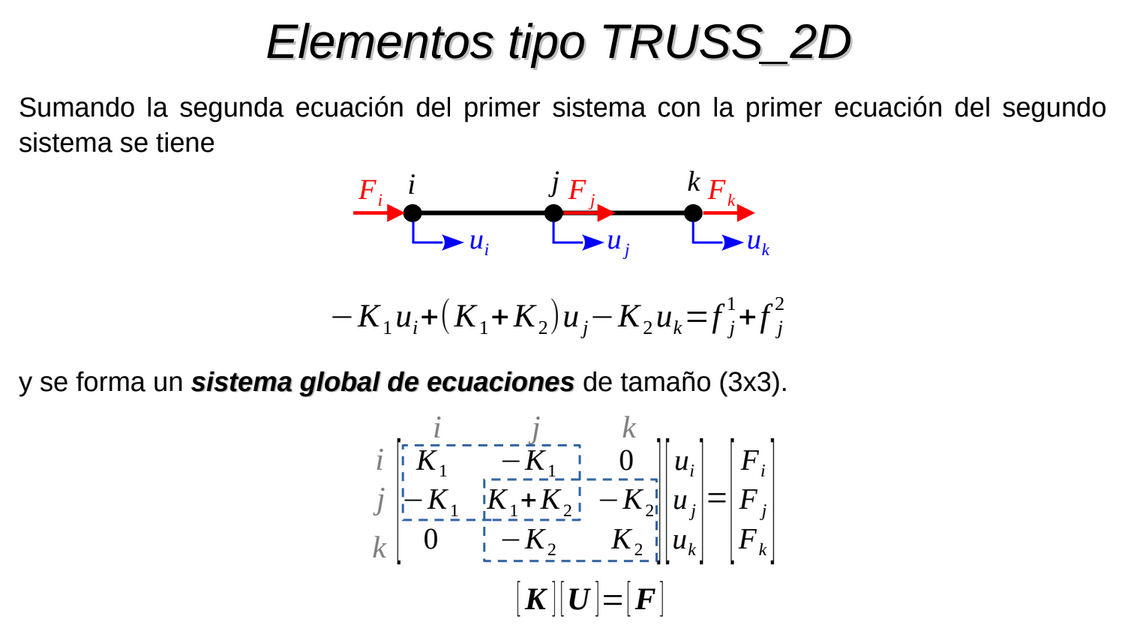
* Como este método es usado para resolver problemas extensos ensamblar manualmente es una tarea que se programa y automatiza
Para eso desarrollamos una función que se enecargue de hacer este proceso de ensamblar las matrices elementales que hemos creado
* Miren siempre los argumentos de una función para que la puedan programar y tenga una ruta obvia de lo que deben hacer
  

In [2]:
def K_G(Melem, Mnod, KG, E_col=2, A_col=3):
    """
    Ensambla la matriz global de rigidez (KG) a partir de las matrices elementales.

    Parámetros:
    ------------
    Melem : ndarray
        Matriz de conectividades y propiedades de los elementos (nodo1, nodo2, E, A).
    Mnod : ndarray
        Matriz de nodos con coordenadas.
    KG : ndarray
        Matriz global de rigidez a modificar.
    E_col : int, opcional
        Índice de columna donde se encuentra el módulo de elasticidad E en Melem.
    A_col : int, opcional
        Índice de columna donde se encuentra el área A en Melem.

    Retorna:
    ---------
    KG : ndarray
        Matriz global de rigidez ensamblada.
    """
    Nelem = Melem.shape[0]
    for e in range(Nelem):
        Ke = K_e(Mnod, Melem, e)
        nod1 = int(Melem[e, 0]) - 1
        nod2 = int(Melem[e, 1]) - 1
        dofs = [nod1, nod2]
        for i in range(len(dofs)): # Bloque ensamblador, siempre se mueve con los grados de libertad
            for j in range(len(dofs)):
                KG[dofs[i], dofs[j]] += Ke[i, j]
    return KG
    

# Los no negociables en una simulación o problema de modelamiento ?
Siempre, siempre se deben imponer condiciones de contorno. 
Que es una condición de contorno---> una (señal, estimulo, valor, condicion valga la redudancia) que condiciona el problema.
Para nuestro problema actual solo existen dos posible condiciones de contorno o estimulos sobre el problema
Vectores de carga, es decir, cuanta fuerza se aplica en cada nodo 
Tipo de contacto, junta o restricción. (Se mueve o no se mueve) (más adelante como se mueve)
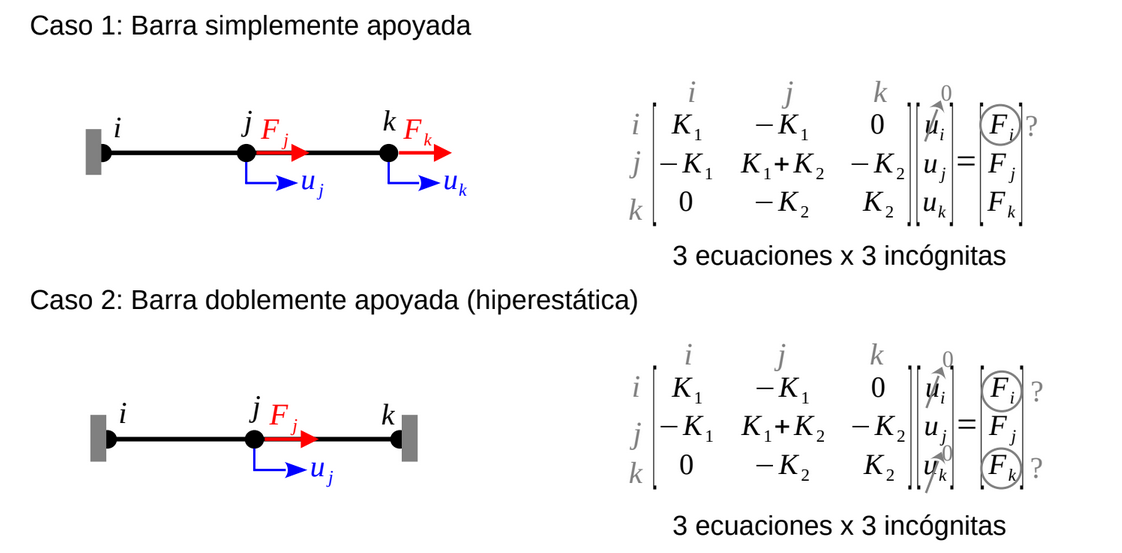

In [3]:
def F_G(Nnod, Load, FG):
    """
    Aplica las cargas nodales al vector global de fuerzas.

    Parámetros:
    ------------
    Nnod : int
        Número total de nodos del sistema.
    Load : ndarray
        Vector de cargas nodales (puede ser 1D o 2D).
    FG : ndarray
        Vector global de fuerzas (modificado en el proceso).

    Retorna:
    ---------
    FG : ndarray
        Vector global de fuerzas con las cargas aplicadas.
    """
    FG[:, 0] = Load.flatten()
    return FG


def penalizacion(Mpenalizacion, Vpenalizacion, bc_dofs, bc_values, kappa=1e15):
    """
    Aplica la técnica de penalización a los grados de libertad restringidos.

    Parámetros:
    ------------
    Mpenalizacion : ndarray
        Matriz global de rigidez sobre la cual se aplicará la penalización.
    Vpenalizacion : ndarray
        Vector global de fuerzas sobre el cual se aplicará la penalización.
    bc_dofs : ndarray
        Matriz de índices de grados de libertad restringidos (n x 1).
    bc_values : ndarray
        Matriz de valores prescritos (n x 1).
    kappa : float, opcional
        Valor grande usado para imponer la condición de frontera.

    Retorna:
    ---------
    Mpenalizacion, Vpenalizacion : tuple(ndarray, ndarray)
        Matriz y vector penalizados.
    """
    for i in range(len(bc_dofs)):
        idx = bc_dofs[i, 0]
        Mpenalizacion[idx, idx] += kappa
        Vpenalizacion[idx] += kappa * bc_values[i, 0]
    return Mpenalizacion, Vpenalizacion


def calcular_reacciones(KG_no_penalty, UG, FG):
    """
    Calcula las reacciones en los apoyos a partir del equilibrio interno.

    Parámetros:
    ------------
    KG_no_penalty : ndarray
        Matriz global de rigidez sin penalización.
    UG : ndarray
        Vector global de desplazamientos.
    FG : ndarray
        Vector global de fuerzas aplicadas.

    Retorna:
    ---------
    reactions : ndarray
        Vector de reacciones en los grados de libertad restringidos.
    """
    internal = KG_no_penalty @ UG
    reactions = internal - FG
    return reactions


* La ultima función solo se encarga de calcular las reacciones en los apoyos en donde la condición de contorno es igual a cero

* Ahora la ruta de proceso del algoritmo consiste:

    1. Parámetros del problema o datos de entrada ¿(qué es y cómo es)?
    2. Definir una geometría en donde va a vivir la malla y sera constante*
    3. Crear matrices elementales y ensamblarlar
    4. Definir condiciones de contorno (cargas + desplazamientos)
    5. Posprocesar (colores, graficas y ser feliz :))
  

Desplazamientos nodales (m):
[4.34782003e-11 3.45992873e-06 6.52179971e-12]

Reacción en A: -43478.200 N
Reacción en D: -6521.800 N


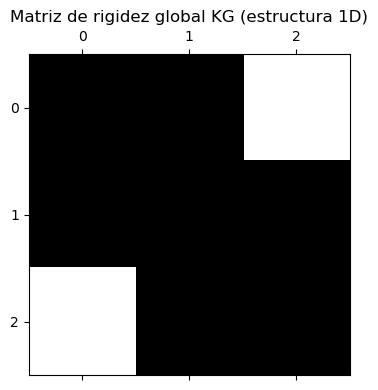

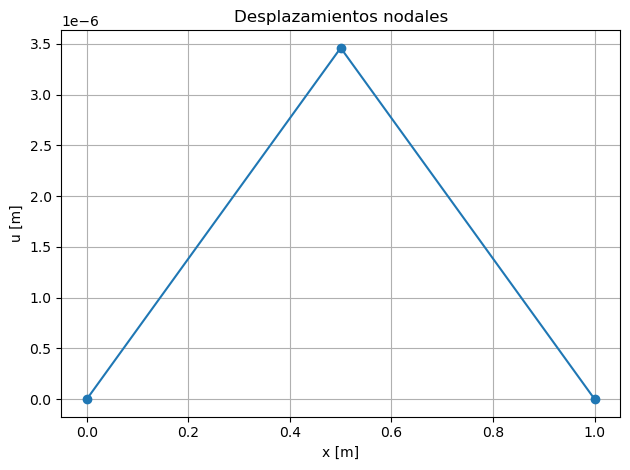

In [4]:
# ==========================
# Datos de entrada
# ==========================
P = 50e3       # Carga en el punto medio de la barra [N] (en el nodo medio)
L = 0.5        # Longitud de cada barra [m]
R = 10e-2      # Radio barra de acero [m]
r = 5e-2       # Radio barra de bronce [m]
Eac = 200e9    # Módulo de elasticidad acero [Pa]
Ebr = 120e9    # Módulo de elasticidad bronce [Pa]
Aac = np.pi * R**2   # Área acero [m²]
Abr = np.pi * r**2   # Área bronce [m²]
DeltaC = 0 #holgura del nodo sin apoyo
# Mallado (2 elementos en serie)
# Nodos: 1 (x=0) - 2 (x=L) - 3 (x=2L)
Mnod = np.array([[0.0, 0.0],
                 [L,   0.0],
                 [2*L, 0.0]], dtype=np.float64)
# Elementos: [nodo1, nodo2, E, A]
Melem = np.array([[1, 2, Eac, Aac],
                  [2, 3, Ebr, Abr]], dtype=np.float64)
Nnod = Mnod.shape[0]
Nelem = Melem.shape[0]
# Definir el vector de cargas
#%%
Load = np.array([0.0, P, 0.0],dtype=np.float64)
# Ensamble del sistema de elementos (ecuaciones)
KG = np.zeros((Nnod, Nnod), dtype=np.float64)
FG = np.zeros((Nnod,1), dtype=np.float64)
KG = K_G(Melem, Mnod,KG)
FG = F_G(Nnod, Load,FG)
#%%
# Guardamos KG sin penalización para calcular reacciones luego
KG_no_penalizacion = KG.copy()
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
# Condiciones de frontera (apoyos en nodo 1 y nodo 3 => desplazamiento 0)
bc_dofs = np.array([[0], [2]],dtype=np.int64)           # índices 0-based de los nodos apoyados
bc_values = np.array([[0.0], [0.0]],dtype=np.float64)   # desplazamientos prescritos
kappa = 1e15
Mpenaliz = np.zeros((Nnod, Nnod), dtype=np.float64)
Vpenaliz =  np.zeros((Nnod, 1),dtype=np.float64)
Mpenaliz, Vpenaliz = penalizacion(KG, FG, bc_dofs, bc_values, kappa=kappa)
# Resolver sistema
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)   # UG es (Nnod,) vector
# Convertir a columna para consistencia
UG_col = UG.reshape((-1,))
# Postprocesamiento: gráfica de desplazamientos a lo largo de x
x = Mnod[:, 0]
plt.figure()
plt.plot(x, UG_col, marker='o')  # sin especificar colores (regla del entorno)
plt.grid(True)
plt.xlabel('x [m]')
plt.ylabel('u [m]')
plt.title('Desplazamientos nodales')
plt.tight_layout()
# Calcular reacciones usando KG sin penalización
reactions = calcular_reacciones(KG_no_penalizacion, UG_col, FG)
RA = reactions[0,0]
RC = reactions[2,2]
print(f"Desplazamientos nodales (m):\n{UG_col}\n")
print(f"Reacción en A: {RA:.3f} N")
print(f"Reacción en D: {RC:.3f} N")
# Mostrar figuras
plt.show()

Desplazamientos nodales (m):
[4.83954596e-11 3.85123671e-06 3.00000160e-06]

Reacción en A: -48395.460 N
Reacción en D: -3000001604.540 N


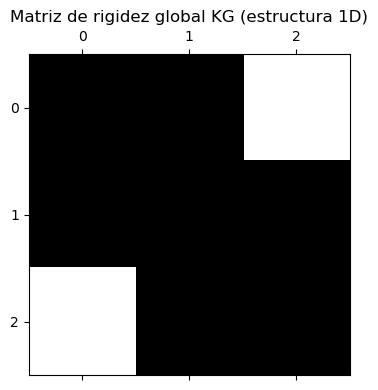

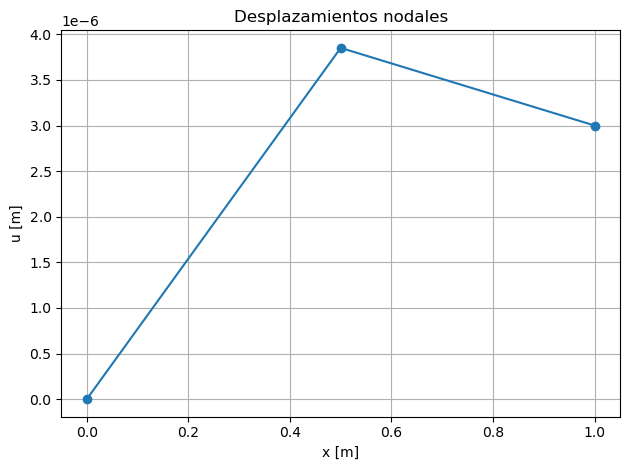

In [5]:
# ==========================
# Datos de entrada
# ==========================
P = 50e3       # Carga en el punto medio de la barra [N] (en el nodo medio)
L = 0.5        # Longitud de cada barra [m]
R = 10e-2      # Radio barra de acero [m]
r = 5e-2       # Radio barra de bronce [m]
Eac = 200e9    # Módulo de elasticidad acero [Pa]
Ebr = 120e9    # Módulo de elasticidad bronce [Pa]
Aac = np.pi * R**2   # Área acero [m²]
Abr = np.pi * r**2   # Área bronce [m²]
DeltaC = 3e-6 #holgura del nodo sin apoyo
# Mallado (2 elementos en serie)
# Nodos: 1 (x=0) - 2 (x=L) - 3 (x=2L)
Mnod = np.array([[0.0, 0.0],
                 [L,   0.0],
                 [2*L, 0.0]], dtype=np.float64)
# Elementos: [nodo1, nodo2, E, A]
Melem = np.array([[1, 2, Eac, Aac],
                  [2, 3, Ebr, Abr]], dtype=np.float64)
Nnod = Mnod.shape[0]
Nelem = Melem.shape[0]
# Definir el vector de cargas
#%%
Load = np.array([0.0, P, 0.0],dtype=np.float64)
# Ensamble del sistema de elementos (ecuaciones)
KG = np.zeros((Nnod, Nnod), dtype=np.float64)
FG = np.zeros((Nnod,1), dtype=np.float64)
KG = K_G(Melem, Mnod,KG)
FG = F_G(Nnod, Load,FG)
#%%
# Guardamos KG sin penalización para calcular reacciones luego
KG_no_penalizacion = KG.copy()
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
# Condiciones de frontera (apoyos en nodo 1 y nodo 3 => desplazamiento 0)
bc_dofs = np.array([[0],[2]],dtype=np.int64)           # índices 0-based de los nodos apoyados
bc_values = np.array([[0.0],[DeltaC]],dtype=np.float64)   # desplazamientos prescritos
kappa = 1e15
Mpenaliz = np.zeros((Nnod, Nnod), dtype=np.float64)
Vpenaliz =  np.zeros((Nnod, 1),dtype=np.float64)
Mpenaliz, Vpenaliz = penalizacion(KG, FG, bc_dofs, bc_values, kappa=kappa)
# Resolver sistema
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)   # UG es (Nnod,) vector
# Convertir a columna para consistencia
UG_col = UG.reshape((-1,))
# Postprocesamiento: gráfica de desplazamientos a lo largo de x
x = Mnod[:, 0]
plt.figure()
plt.plot(x, UG_col, marker='o')  # sin especificar colores (regla del entorno)
plt.grid(True)
plt.xlabel('x [m]')
plt.ylabel('u [m]')
plt.title('Desplazamientos nodales')
plt.tight_layout()
# Calcular reacciones usando KG sin penalización
reactions = calcular_reacciones(KG_no_penalizacion, UG_col, FG)
RA = reactions[0,0]
RC = reactions[2,2]
print(f"Desplazamientos nodales (m):\n{UG_col}\n")
print(f"Reacción en A: {RA:.3f} N")
print(f"Reacción en D: {RC:.3f} N")
# Mostrar figuras
plt.show()

numero de nodos: 10
numero de elementos: 9
Desplazamientos nodales (m):
[[1.92374069e-12]
 [3.48708147e-08]
 [6.66658372e-08]
 [9.52306520e-08]
 [1.20375141e-07]
 [1.41865767e-07]
 [1.59412437e-07]
 [1.72650285e-07]
 [1.81113933e-07]
 [1.84200353e-07]]

Reacción en A: -1923.741 N


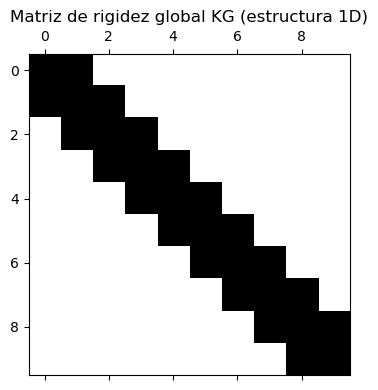

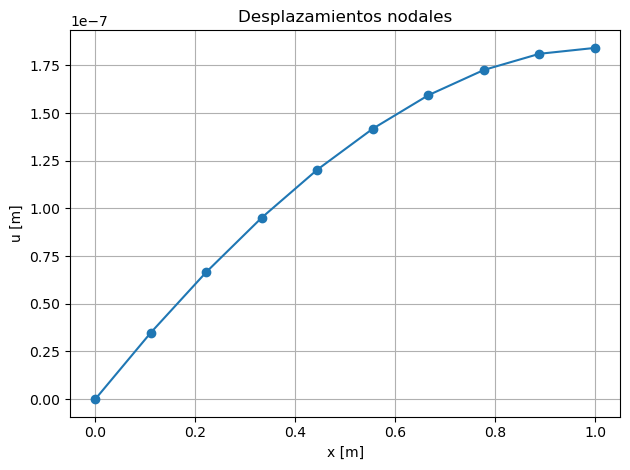

In [6]:
elementos = 10
L = 1
R = 0.25         # Radio mayor [m]
r = 0.15         # Radio menor [m]
deltax = L/elementos
Mnod = np.linspace(0,L,elementos)
Mnod = Mnod.reshape(-1,1)
vec0 = np.zeros([elementos,1])
Mnod = np.column_stack((Mnod,vec0))
Melem = np.zeros([Mnod.shape[0]-1,4])
Nnod = Mnod.shape[0]
Nelem = Melem.shape[0]
# Ensamble del sistema de elementos (ecuaciones)
KG = np.zeros((Nnod, Nnod), dtype=np.float64)
FG = np.zeros((Nnod,1), dtype=np.float64)
for i in range(Nelem):
    Melem[i,0] = i+1
    Melem[i,1] = Melem[i,0]+1
    Melem[i,2] = 30e9
    x1, x2 = Mnod[i,0], Mnod[i+1,0]
    xmed = 0.5 * (x1 + x2)
    A = np.pi*(((r - R) * xmed + R) ** 2)
    Melem[i,3] = A
    gamma = 15e3
    W = A * (x2-x1) * gamma # Calcular la fuerza de cada elementos con la longitud del elemento
    FG[i] += W / 2
    FG[i+1] += W / 2
print("numero de nodos:",Nnod)
print("numero de elementos:",Nelem)
# Ensamble de la matriz
KG = K_G(Melem, Mnod,KG)
# Guardamos KG sin penalización para calcular reacciones luego
KG_no_penalizacion = KG.copy()
# Visualización de la matriz de rigidez global
plt.figure(figsize=(5,4))
plt.spy(KG)
plt.title("Matriz de rigidez global KG (estructura 1D)")
plt.tight_layout()
# Condiciones de frontera (apoyos en nodo 1 y nodo 3 => desplazamiento 0)
bc_dofs = np.array([[0]],dtype=np.int64)           # índices 0-based de los nodos apoyados
bc_values = np.array([[0.0]],dtype=np.float64)   # desplazamientos prescritos
kappa = 1e15
Mpenaliz = np.zeros((Nnod, Nnod), dtype=np.float64)
Vpenaliz =  np.zeros((Nnod, 1),dtype=np.float64)
Mpenaliz, Vpenaliz = penalizacion(KG, FG, bc_dofs, bc_values, kappa=kappa)
# Resolver sistema
UG = np.linalg.solve(KG + Mpenaliz, FG + Vpenaliz)   # UG es (Nnod,) vector
# Convertir a columna para consistencia
UG_col = UG.reshape((-1,))
# Postprocesamiento: gráfica de desplazamientos a lo largo de x
x = Mnod[:, 0]
plt.figure()
plt.plot(x, UG_col, marker='o')  # sin especificar colores (regla del entorno)
plt.grid(True)
plt.xlabel('x [m]')
plt.ylabel('u [m]')
plt.title('Desplazamientos nodales')
plt.tight_layout()
reactions = calcular_reacciones(KG_no_penalizacion, UG_col, FG)
RA = reactions[0,0]
print(f"Desplazamientos nodales (m):\n{UG}\n")
print(f"Reacción en A: {RA:.3f} N")